# Laboratorio N.º 04: Generación de Variables Aleatorias Continuas

**Curso:** Simulación Computacional · Universidad de los Llanos · Escuela de Ingeniería

**Estudiante:** Duván Felipe Baquero · **Código:** 160005002

**Docente:** Ángel Alfonso Cruz Roa

Guía FO-DOC-112, Práctica N.º 04. El cuaderno sigue el orden de la guía:

| Sección | Contenido |
|---|---|
| 1 | Objetivos |
| 2 | Consulta previa |
| 3 | Fundamento teórico (resumen de los métodos usados) |
| 5.1 | Literales a) a d): 1000 valores de cada distribución, histograma y densidad teórica |
| 5.2 | a) Proceso de Poisson en $[0, T]$; b) variable aleatoria de Coxian |
| 5.3 | Proceso de Poisson no homogéneo en $[0, 10]$ |

Todos los números aleatorios salen de un generador congruencial mixto escrito a mano. De `scipy` solo
se usan las densidades y acumuladas teóricas para comparar, la prueba de Kolmogorov-Smirnov y una
integración numérica para las medias teóricas. Las semillas están fijas, así que el cuaderno da los
mismos resultados cada vez que se ejecuta.

## 1. Objetivos

- Generar secuencias de valores de una variable aleatoria de una distribución de probabilidad continua.
- Generar valores aleatorios de una distribución de probabilidad continua usando el método de la transformada inversa.
- Generar valores aleatorios de una distribución de probabilidad continua usando el método del rechazo.
- Generar valores aleatorios de una distribución de probabilidad continua usando el método polar para generar variables aleatorias normales.
- Generar valores aleatorios de una distribución de exponencial.
- Generar valores aleatorios de una distribución de probabilidad Gamma.
- Generar valores aleatorios de una distribución de probabilidad Normal estandar.
- Generar variables aleatorias de procesos de Poisson y procesos de Poisson no homogéneos.

## 2. Consulta previa

**¿Qué es una variable aleatoria?**

Es una función que le asigna un número real a cada resultado de un experimento aleatorio. Gracias a
eso se puede trabajar con probabilidades usando números en lugar de eventos. En este laboratorio son
variables aleatorias, por ejemplo, el tiempo que un trabajador tarda en terminar su tarea (5.2 b) o el
número de eventos de un proceso de Poisson hasta el tiempo $T$.

**¿Qué es una distribución de probabilidad?**

Es la descripción de cómo se reparte la probabilidad entre los valores que puede tomar la variable.
Siempre se puede dar con la función de distribución acumulada $F(x) = P\{X \le x\}$, que es no
decreciente y va de 0 a 1. Si la variable es discreta se usa además la función de masa
$p(x_i) = P\{X = x_i\}$, y si es continua la función de densidad $f(x)$, con
$P\{a \le X \le b\} = \int_a^b f(x)\,dx$.

**¿Cuál es la diferencia entre una distribución de probabilidad discreta y una continua?**

En la discreta la variable toma valores aislados (finitos o numerables) y cada uno tiene probabilidad
positiva, por eso las probabilidades se suman. En la continua la variable puede caer en cualquier
punto de un intervalo, la probabilidad de un valor exacto es cero y las probabilidades se obtienen
integrando la densidad. Para generarlas también cambia la cosa: en el laboratorio anterior la
transformada inversa se hacía buscando en una tabla de probabilidades acumuladas, y aquí se hace
despejando $x$ de la ecuación $F(x) = U$.

**¿Cuál es la definición de la distribución de probabilidad exponencial?**

$X$ es exponencial con tasa $\lambda > 0$ si su densidad es

$$f(x) = \lambda e^{-\lambda x}, \qquad x \ge 0,$$

con acumulada $F(x) = 1 - e^{-\lambda x}$, media $1/\lambda$ y varianza $1/\lambda^2$. Es la única
distribución continua sin memoria: $P\{X > s + t \mid X > s\} = P\{X > t\}$. Esa propiedad es la que
la vuelve el modelo natural para tiempos entre llegadas.

**¿Cuál es la definición de la distribución de probabilidad Gamma y sus parámetros?**

$X$ tiene distribución Gamma con parámetros $(n, \lambda)$ si

$$f(x) = \frac{\lambda e^{-\lambda x}(\lambda x)^{n-1}}{\Gamma(n)}, \qquad x \ge 0,$$

donde $n > 0$ es el parámetro de forma, $\lambda > 0$ el de tasa y
$\Gamma(n) = \int_0^\infty e^{-y}y^{n-1}dy$. Su media es $n/\lambda$ y su varianza $n/\lambda^2$.
Cuando $n$ es entero, $X$ tiene la misma distribución que la suma de $n$ exponenciales
independientes de tasa $\lambda$, y así es como se genera en este cuaderno. Con $n = 1$ se
recupera la exponencial.

**¿Cuál es la definición de la distribución de probabilidad normal estándar y sus parámetros?**

Es la normal con media $\mu = 0$ y desviación estándar $\sigma = 1$:

$$f(z) = \frac{1}{\sqrt{2\pi}}\,e^{-z^2/2}, \qquad -\infty < z < \infty.$$

Cualquier normal $N(\mu, \sigma^2)$ se obtiene de ella como $X = \mu + \sigma Z$. Su acumulada no
tiene forma cerrada, así que la transformada inversa directa no sirve y hay que recurrir al rechazo o
al método polar.

**¿Qué es un proceso de Poisson y un proceso de Poisson no homogéneo? ¿Cuál es la diferencia entre ellos?**

Un proceso de Poisson de tasa $\lambda$ es un proceso de conteo $\{N(t), t \ge 0\}$ con $N(0) = 0$,
incrementos independientes y estacionarios, y tal que el número de eventos en cualquier intervalo de
longitud $t$ es Poisson de media $\lambda t$. Una consecuencia directa es que los tiempos entre
eventos son exponenciales independientes de tasa $\lambda$.

En el no homogéneo la tasa cambia con el tiempo y se describe con una función de intensidad
$\lambda(t)$. Los incrementos siguen siendo independientes, pero ya no estacionarios: el número de
eventos entre $s$ y $s + t$ es Poisson de media $\int_s^{s+t}\lambda(y)\,dy$. La diferencia práctica
es que en el homogéneo da lo mismo en qué momento se mire una ventana de tiempo, mientras que en el
no homogéneo no (por ejemplo, las llegadas a un restaurante a las 7 a.m. y al mediodía). Por eso en
el no homogéneo los tiempos entre eventos ya no son exponenciales iguales y hay que generarlos con
otro algoritmo, como el de adelgazamiento.

## 3. Fundamento teórico

Resumen de lo que se usa de las diapositivas y del capítulo 5 de [Ross99].

**Transformada inversa (sección 5.1).** Si $U \sim U(0,1)$ y $F$ es una acumulada continua, entonces
$X = F^{-1}(U)$ tiene acumulada $F$. Sirve cuando se puede despejar $x$ de $F(x) = u$.

**Rechazo (sección 5.2).** Si se sabe generar $Y$ con densidad $g$ y existe $c$ tal que
$f(y)/g(y) \le c$ para todo $y$, se genera $Y$ y $U$ y se acepta $X = Y$ cuando
$U \le f(Y)/(c\,g(Y))$; si no, se repite. El número de iteraciones es geométrico de media $c$.

**Método polar (sección 5.3).** Se generan $V_1, V_2 \sim U(-1,1)$ hasta que $S = V_1^2 + V_2^2 \le 1$
y se devuelven $X = V_1\sqrt{-2\ln S / S}$ y $Y = V_2\sqrt{-2\ln S / S}$, dos normales estándar
independientes. Se acepta un par con probabilidad $\pi/4$.

**Proceso de Poisson (sección 5.4).** Los tiempos entre eventos son exponenciales de tasa $\lambda$,
así que basta acumular $-\frac{1}{\lambda}\ln U$ hasta pasar de $T$.

**Proceso de Poisson no homogéneo (sección 5.5).** Con $\lambda(t) \le \lambda$ en $[0, T]$ se genera
un proceso homogéneo de tasa $\lambda$ y cada evento en el tiempo $t$ se conserva con probabilidad
$\lambda(t)/\lambda$ (adelgazamiento). Ross muestra también una versión que parte $[0,T]$ en
subintervalos con cotas $\lambda_j$ distintas para rechazar menos.

---

## 5. Procedimiento

### Librerías y generador de números pseudoaleatorios

La nota de la guía pide usar generadores congruenciales mixtos que cumplan los criterios de
uniformidad y aleatoriedad. Se usa $X_{n+1} = (aX_n + c) \bmod m$ con $a = 25214903917$, $c = 11$ y
$m = 2^{48}$, que en el Laboratorio 2 fue el único que pasó todas las pruebas con periodo completo.
Primero se revisan las condiciones de Hull-Dobell y después se prueban 10 000 valores.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate
from scipy.linalg import expm

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
COLOR_HIST, COLOR_LINEA = "#9ecae1", "#b22222"

In [2]:
class GCM:
    # Generador congruencial mixto: X_{n+1} = (a*X_n + c) mod m,  U = X/m
    def __init__(self, semilla, a=25214903917, c=11, m=2**48):
        self.a, self.c, self.m = a, c, m
        self.x = semilla % m

    def u(self):
        # se salta el estado 0 para que ln(U) nunca falle (pasa una vez cada 2^48 números)
        while True:
            self.x = (self.a * self.x + self.c) % self.m
            if self.x != 0:
                return self.x / self.m

    def uniformes(self, n):
        return np.array([self.u() for _ in range(n)])


def factores_primos(n):
    f, p = set(), 2
    while p * p <= n:
        while n % p == 0:
            f.add(p); n //= p
        p += 1
    if n > 1:
        f.add(n)
    return f

a, c, m = 25214903917, 11, 2**48
print("Condiciones de Hull-Dobell para a = 25214903917, c = 11, m = 2^48")
print("  1) mcd(c, m) = 1 :", math.gcd(c, m) == 1)
print("  2) todo primo que divide a m divide a (a-1):",
      all((a - 1) % p == 0 for p in factores_primos(m)), " primos de m:", factores_primos(m))
print("  3) si 4 divide a m, 4 divide a (a-1):", (a - 1) % 4 == 0)
print("  -> periodo completo m =", m)

Condiciones de Hull-Dobell para a = 25214903917, c = 11, m = 2^48
  1) mcd(c, m) = 1 : True
  2) todo primo que divide a m divide a (a-1): True  primos de m: {2}
  3) si 4 divide a m, 4 divide a (a-1): True
  -> periodo completo m = 281474976710656


In [3]:
def prueba_rachas(u):
    # rachas ascendentes y descendentes
    signos = np.sign(np.diff(u))
    signos = signos[signos != 0]
    R = 1 + np.count_nonzero(signos[1:] != signos[:-1])
    n = len(u)
    media, var = (2 * n - 1) / 3, (16 * n - 29) / 90
    z = (R - media) / math.sqrt(var)
    return R, z, 2 * (1 - stats.norm.cdf(abs(z)))

def prueba_chi2(u, k=20):
    obs, _ = np.histogram(u, bins=k, range=(0, 1))
    esp = len(u) / k
    chi2 = ((obs - esp) ** 2 / esp).sum()
    return chi2, 1 - stats.chi2.cdf(chi2, k - 1)

u_prueba = GCM(semilla=20260925).uniformes(10_000)
ks = stats.kstest(u_prueba, "uniform")
chi2, p_chi2 = prueba_chi2(u_prueba)
R, z, p_rachas = prueba_rachas(u_prueba)

pruebas = pd.DataFrame({
    "Prueba": ["Kolmogorov-Smirnov", "Chi-cuadrado (20 clases)", "Rachas arriba/abajo"],
    "Estadístico": [ks.statistic, chi2, z],
    "Valor p": [ks.pvalue, p_chi2, p_rachas],
})
pruebas["Decisión (alfa = 0,05)"] = np.where(pruebas["Valor p"] > 0.05, "No se rechaza H0", "Se rechaza H0")
print(f"n = {len(u_prueba)}   media = {u_prueba.mean():.4f} (teórica 0,5)   varianza = {u_prueba.var():.4f} (teórica 0,0833)   rachas R = {R}")
pruebas

n = 10000   media = 0.4977 (teórica 0,5)   varianza = 0.0838 (teórica 0,0833)   rachas R = 6705


,Prueba,Estadístico,Valor p,"Decisión (alfa = 0,05)"
0,Kolmogorov-Smirnov,0.0071,0.6964,No se rechaza H0
1,Chi-cuadrado (20 clases),11.8400,0.8923,No se rechaza H0
2,Rachas arriba/abajo,0.9171,0.3591,No se rechaza H0


El generador pasa las tres pruebas, así que se puede usar como fuente de $U(0,1)$. A partir de aquí
cada literal crea su propia instancia `GCM` con una semilla distinta para que los resultados de un
literal no dependan de cuántos números consumió el anterior.

### Generadores de apoyo: exponencial, Gamma y normal estándar (método polar)

Los objetivos piden además generar exponenciales, Gamma y normales estándar. La exponencial se usa
luego en los procesos de Poisson y en la variable de Coxian, así que se deja definida aquí.

- Exponencial por transformada inversa: $X = -\frac{1}{\lambda}\ln U$.
- Gamma$(n, \lambda)$ con $n$ entero como suma de $n$ exponenciales: $X = -\frac{1}{\lambda}\ln(U_1 U_2 \cdots U_n)$.
- Normal estándar con el método polar.

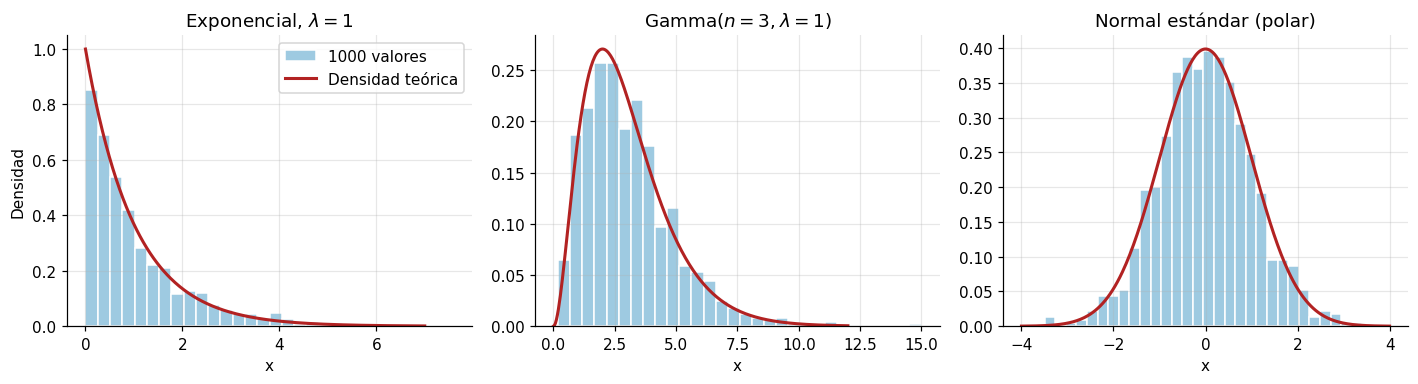

Método polar: 628 intentos para 500 pares, tasa de aceptación = 0.7962 (teórica pi/4 = 0.7854)


,Distribución,Media sim.,Media teór.,Var. sim.,Var. teór.,D (KS),Valor p
0,Exponencial(1),1.0525,1.0000,1.1401,1.0000,0.0281,0.4021
1,"Gamma(3, 1)",3.0796,3.0000,3.3469,3.0000,0.0338,0.1987
2,"Normal(0, 1)",0.0096,0.0000,1.0313,1.0000,0.0203,0.7969


In [4]:
def exponencial(g, lam):
    return -math.log(g.u()) / lam

def gamma_n(g, n, lam):
    prod = 1.0
    for _ in range(n):
        prod *= g.u()
    return -math.log(prod) / lam

def normales_polar(g):
    # devuelve dos normales estándar independientes y los intentos que tomó
    intentos = 0
    while True:
        intentos += 1
        v1, v2 = 2 * g.u() - 1, 2 * g.u() - 1
        s = v1 * v1 + v2 * v2
        if 0 < s <= 1:
            k = math.sqrt(-2 * math.log(s) / s)
            return v1 * k, v2 * k, intentos

g = GCM(semilla=11)
x_exp = np.array([exponencial(g, 1.0) for _ in range(1000)])
x_gam = np.array([gamma_n(g, 3, 1.0) for _ in range(1000)])
pares = [normales_polar(g) for _ in range(500)]
x_nor = np.array([p[0] for p in pares] + [p[1] for p in pares])
intentos_polar = sum(p[2] for p in pares)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
casos = [(x_exp, stats.expon(), np.linspace(0, 7, 300), "Exponencial, $\\lambda = 1$"),
         (x_gam, stats.gamma(3), np.linspace(0, 12, 300), "Gamma$(n=3, \\lambda=1)$"),
         (x_nor, stats.norm(), np.linspace(-4, 4, 300), "Normal estándar (polar)")]
for ax, (x, dist, xs, tit) in zip(axs, casos):
    ax.hist(x, bins=30, density=True, color=COLOR_HIST, edgecolor="white", label="1000 valores")
    ax.plot(xs, dist.pdf(xs), color=COLOR_LINEA, lw=2, label="Densidad teórica")
    ax.set_title(tit); ax.set_xlabel("x")
axs[0].set_ylabel("Densidad"); axs[0].legend()
plt.tight_layout(); plt.show()

apoyo = pd.DataFrame({
    "Distribución": ["Exponencial(1)", "Gamma(3, 1)", "Normal(0, 1)"],
    "Media sim.": [x_exp.mean(), x_gam.mean(), x_nor.mean()],
    "Media teór.": [1.0, 3.0, 0.0],
    "Var. sim.": [x_exp.var(ddof=1), x_gam.var(ddof=1), x_nor.var(ddof=1)],
    "Var. teór.": [1.0, 3.0, 1.0],
    "D (KS)": [stats.kstest(x, d.cdf).statistic for x, d, _, _ in casos],
    "Valor p": [stats.kstest(x, d.cdf).pvalue for x, d, _, _ in casos],
})
print(f"Método polar: {intentos_polar} intentos para 500 pares, tasa de aceptación = {500/intentos_polar:.4f} (teórica pi/4 = {math.pi/4:.4f})")
apoyo

Las tres muestras siguen su densidad teórica y ninguna es rechazada por Kolmogorov-Smirnov. En el
método polar la fracción de pares aceptados queda muy cerca de $\pi/4 \approx 0{,}785$, que es la
proporción del cuadrado $[-1,1]^2$ que ocupa el círculo unitario.

Para no repetir código en el 5.1 se define una función que dibuja el histograma contra la densidad y
otra que resume la muestra (media, varianza y Kolmogorov-Smirnov). Las medias y varianzas teóricas se
calculan integrando la densidad numéricamente.

In [5]:
def momentos(pdf, a, b):
    m1 = integrate.quad(lambda x: x * pdf(x), a, b, limit=200)[0]
    m2 = integrate.quad(lambda x: x * x * pdf(x), a, b, limit=200)[0]
    return m1, m2 - m1 ** 2

def resumen(nombre, x, cdf, pdf, a, b):
    media, var = momentos(pdf, a, b)
    ks = stats.kstest(x, cdf)
    return {"Caso": nombre, "Media sim.": x.mean(), "Media teór.": media,
            "Var. sim.": x.var(ddof=1), "Var. teór.": var,
            "D (KS)": ks.statistic, "Valor p": ks.pvalue}

def graficar(ax, x, pdf, xs, titulo, bins=30, etiqueta="Densidad teórica", loc="best"):
    ax.hist(x, bins=bins, density=True, color=COLOR_HIST, edgecolor="white", label=f"{len(x)} valores generados")
    ax.plot(xs, [pdf(v) for v in xs], color=COLOR_LINEA, lw=2, label=etiqueta)
    ax.set_title(titulo); ax.set_xlabel("x"); ax.set_ylabel("Densidad")
    ax.legend(loc=loc)

filas_51 = []

### 5.1 Generación de variables aleatorias continuas

#### a) $f(x) = \dfrac{e^x}{e - 1}$, $\quad 0 \le x \le 1$

Se puede invertir directamente. Integrando la densidad,

$$F(x) = \int_0^x \frac{e^y}{e-1}\,dy = \frac{e^x - 1}{e - 1}, \qquad 0 \le x \le 1.$$

Igualando a $U$ y despejando: $e^x = 1 + (e-1)U$, es decir

$$X = \ln\big(1 + (e - 1)U\big).$$

Método usado: **transformada inversa**.

Primeros 10 valores: [0.0154 0.8854 0.9465 0.3765 0.8389 0.7464 0.1318 0.8349 0.2093 0.7125]


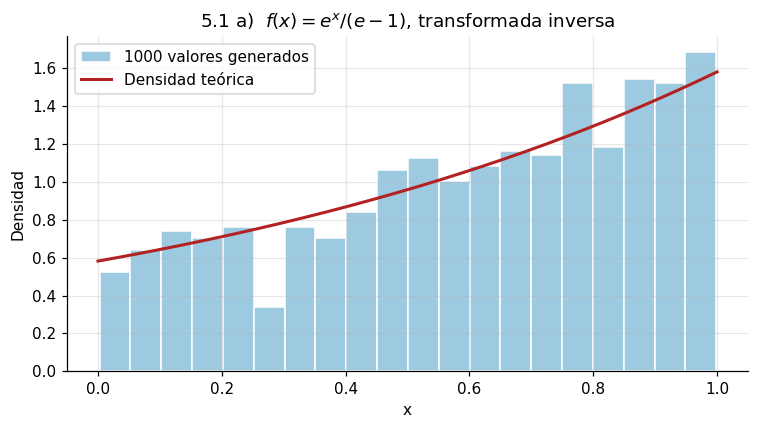

,Caso,Media sim.,Media teór.,Var. sim.,Var. teór.,D (KS),Valor p
0,a) e^x/(e-1),0.5963,0.5820,0.0778,0.0793,0.0353,0.1617


In [6]:
def f_a(x):
    return math.exp(x) / (math.e - 1) if 0 <= x <= 1 else 0.0

def F_a(x):
    x = np.clip(x, 0, 1)
    return (np.exp(x) - 1) / (math.e - 1)

def generar_a(g):
    return math.log(1 + (math.e - 1) * g.u())

g = GCM(semilla=101)
x_a = np.array([generar_a(g) for _ in range(1000)])
print("Primeros 10 valores:", np.round(x_a[:10], 4))

fig, ax = plt.subplots(figsize=(7, 4))
graficar(ax, x_a, f_a, np.linspace(0, 1, 300), "5.1 a)  $f(x) = e^x/(e-1)$, transformada inversa", bins=20)
plt.tight_layout(); plt.show()

filas_51.append(resumen("a) e^x/(e-1)", x_a, F_a, f_a, 0, 1))
pd.DataFrame(filas_51[-1:])

#### b) $f(x) = \dfrac{x-2}{2}$ si $2 \le x \le 3$, $\quad f(x) = \dfrac{2 - x/3}{2}$ si $3 \le x \le 6$

Es una densidad triangular con mínimo 2, moda 3 y máximo 6. Su valor más alto es $f(3) = 1/2$.

**Método del rechazo.** Como la densidad está acotada y su soporte es finito, se toma como
distribución auxiliar la uniforme en $[2, 6]$, con $g(y) = 1/4$. La constante es

$$c = \max_y \frac{f(y)}{g(y)} = \frac{1/2}{1/4} = 2,$$

y la condición de aceptación queda $U \le \dfrac{f(Y)}{c\,g(Y)} = 2f(Y)$. En promedio se necesitan
$c = 2$ iteraciones por valor aceptado.

**Transformada inversa (para comparar).** La acumulada es

$$F(x) = \begin{cases} \dfrac{(x-2)^2}{4}, & 2 \le x \le 3,\\[2mm] x - \dfrac{x^2}{12} - 2, & 3 \le x \le 6,\end{cases}$$

con $F(3) = 1/4$. Despejando cada tramo:
$X = 2 + 2\sqrt{U}$ si $U \le 1/4$, y $X = 6 - 2\sqrt{3(1 - U)}$ si $U > 1/4$.

Se generan los 1000 valores con rechazo, que es el método pedido en los objetivos, y también con la
inversa para comparar el costo.

Primeros 10 valores (rechazo): [2.6581 2.2869 3.2305 2.2863 2.7499 2.0978 3.0829 4.8108 4.8705 4.4155]
Iteraciones promedio por valor aceptado: 1.988 (teórico c = 2)
Números U(0,1) consumidos: rechazo = 3976, inversa = 1000


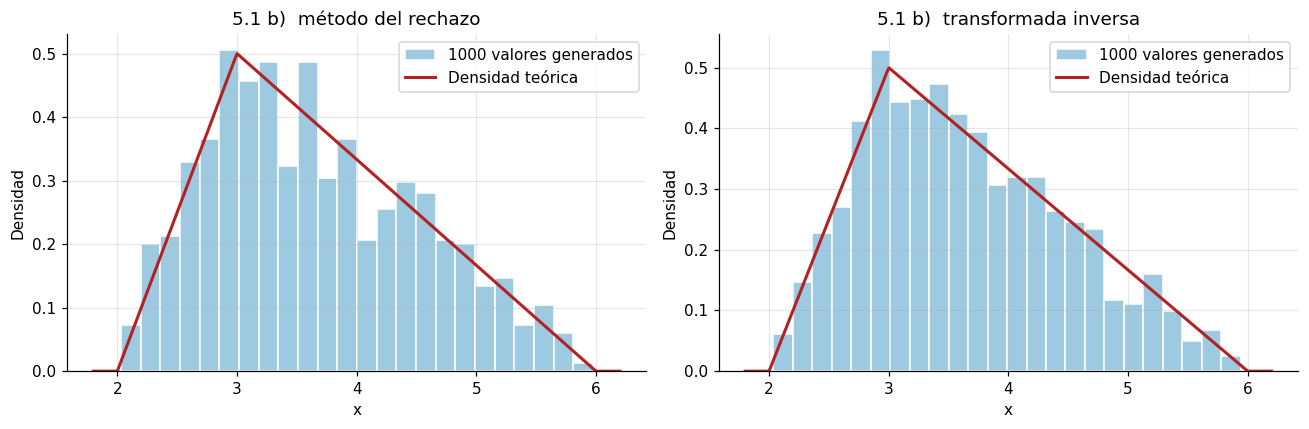

,Caso,Media sim.,Media teór.,Var. sim.,Var. teór.,D (KS),Valor p
0,b) triangular (rechazo),3.6541,3.6667,0.7715,0.7222,0.0271,0.4466
1,b) triangular (inversa),3.6428,3.6667,0.7086,0.7222,0.0206,0.7800


In [7]:
def f_b(x):
    if 2 <= x <= 3:
        return (x - 2) / 2
    if 3 < x <= 6:
        return (2 - x / 3) / 2
    return 0.0

def F_b(x):
    x = np.asarray(x, dtype=float)
    return np.where(x < 2, 0.0,
           np.where(x <= 3, (x - 2) ** 2 / 4,
           np.where(x <= 6, x - x ** 2 / 12 - 2, 1.0)))

C_B = 2.0   # max f(y)/g(y) con g uniforme en [2, 6]

def generar_b_rechazo(g):
    iteraciones = 0
    while True:
        iteraciones += 1
        y = 2 + 4 * g.u()              # Y ~ U(2, 6)
        if g.u() <= f_b(y) / (C_B * 0.25):
            return y, iteraciones

def generar_b_inversa(g):
    u = g.u()
    return 2 + 2 * math.sqrt(u) if u <= 0.25 else 6 - 2 * math.sqrt(3 * (1 - u))

g = GCM(semilla=202)
salida = [generar_b_rechazo(g) for _ in range(1000)]
x_b = np.array([s[0] for s in salida])
iter_b = np.array([s[1] for s in salida])

g2 = GCM(semilla=203)
x_b_inv = np.array([generar_b_inversa(g2) for _ in range(1000)])

print("Primeros 10 valores (rechazo):", np.round(x_b[:10], 4))
print(f"Iteraciones promedio por valor aceptado: {iter_b.mean():.3f} (teórico c = 2)")
print(f"Números U(0,1) consumidos: rechazo = {2 * iter_b.sum()}, inversa = 1000")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
xs = np.linspace(1.8, 6.2, 400)
graficar(axs[0], x_b, f_b, xs, "5.1 b)  método del rechazo", bins=24)
graficar(axs[1], x_b_inv, f_b, xs, "5.1 b)  transformada inversa", bins=24)
plt.tight_layout(); plt.show()

filas_51.append(resumen("b) triangular (rechazo)", x_b, F_b, f_b, 2, 6))
filas_51.append(resumen("b) triangular (inversa)", x_b_inv, F_b, f_b, 2, 6))
pd.DataFrame(filas_51[-2:])

Los dos métodos reproducen la misma forma triangular y ninguno es rechazado por Kolmogorov-Smirnov.
La diferencia está en el costo: el rechazo necesitó cerca de 2 iteraciones por valor, como predice
$c = 2$, y cada iteración usa dos números uniformes, de modo que gastó unas cuatro veces más números
que la inversa. Aquí la inversa es mejor porque la acumulada se puede despejar; el rechazo tiene
sentido cuando eso no es posible.

#### c) $F(x) = \dfrac{x^2 + x}{2}$, $\quad 0 \le x \le 1$

La guía pide transformada inversa. Igualando $F(x) = U$ queda la cuadrática $x^2 + x - 2U = 0$,
cuya raíz en $[0, 1]$ es

$$X = \frac{-1 + \sqrt{1 + 8U}}{2}.$$

La densidad, que se usa para la gráfica, es $f(x) = F'(x) = x + \tfrac{1}{2}$.

Primeros 10 valores: [0.0516 0.6038 0.7607 0.5677 0.6743 0.8261 0.1106 0.4257 0.4777 0.9355]


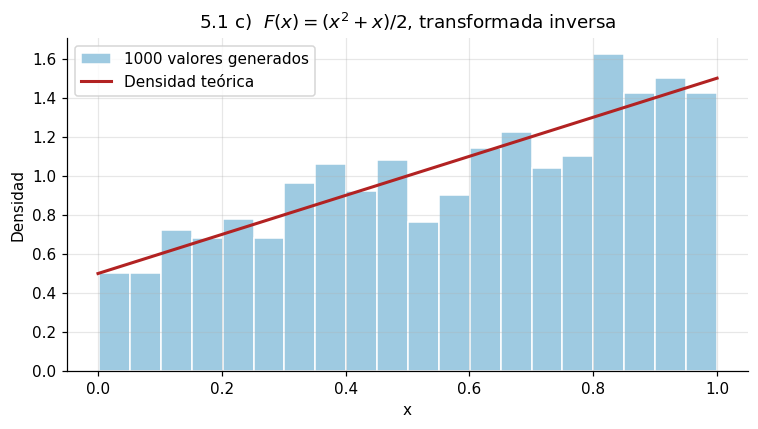

,Caso,Media sim.,Media teór.,Var. sim.,Var. teór.,D (KS),Valor p
0,c) (x^2+x)/2,0.5827,0.5833,0.0771,0.0764,0.0204,0.7897


In [8]:
def f_c(x):
    return x + 0.5 if 0 <= x <= 1 else 0.0

def F_c(x):
    x = np.clip(x, 0, 1)
    return (x ** 2 + x) / 2

def generar_c(g):
    return (-1 + math.sqrt(1 + 8 * g.u())) / 2

g = GCM(semilla=303)
x_c = np.array([generar_c(g) for _ in range(1000)])
print("Primeros 10 valores:", np.round(x_c[:10], 4))

fig, ax = plt.subplots(figsize=(7, 4))
graficar(ax, x_c, f_c, np.linspace(0, 1, 300), "5.1 c)  $F(x) = (x^2+x)/2$, transformada inversa", bins=20)
plt.tight_layout(); plt.show()

filas_51.append(resumen("c) (x^2+x)/2", x_c, F_c, f_c, 0, 1))
pd.DataFrame(filas_51[-1:])

#### d) Weibull: $F(x) = 1 - \exp(-\alpha x^\beta)$, $\quad 0 < x < \infty$

Despejando de $1 - e^{-\alpha x^\beta} = U$ se llega a $X = \left(-\frac{1}{\alpha}\ln(1-U)\right)^{1/\beta}$.
Como $1 - U$ también es $U(0,1)$, se usa la forma equivalente

$$X = \left(-\frac{\ln U}{\alpha}\right)^{1/\beta}.$$

La densidad es $f(x) = \alpha\beta x^{\beta-1}e^{-\alpha x^\beta}$ y la media
$E[X] = \alpha^{-1/\beta}\,\Gamma(1 + 1/\beta)$. La guía no fija $\alpha$ y $\beta$, así que se
prueban tres combinaciones: $\beta = 1$ (se reduce a una exponencial de tasa $\alpha$), $\beta = 2$
(Rayleigh) y $\beta = 3{,}5$ (casi simétrica).

alfa=1.0, beta=1.0: primeros 5 valores [3.3189 1.1648 0.6057 0.6266 0.0362]
alfa=1.0, beta=2.0: primeros 5 valores [1.8211 1.7743 0.9888 0.5569 0.9649]
alfa=0.5, beta=3.5: primeros 5 valores [1.7166 0.8262 1.3884 0.5706 0.7627]


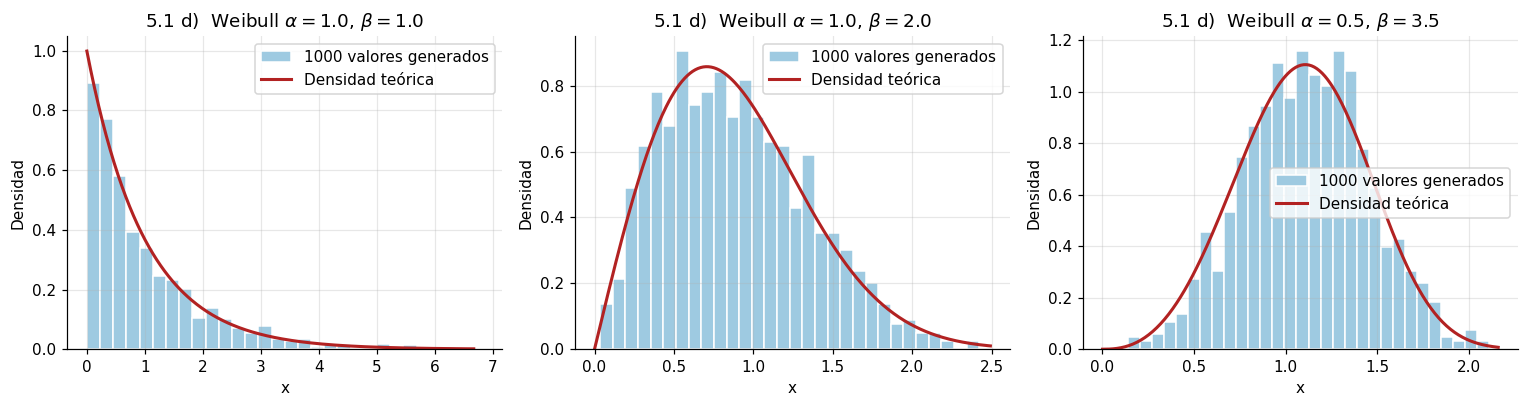

,Caso,Media sim.,Media teór.,Var. sim.,Var. teór.,D (KS),Valor p
0,"d) Weibull a=1.0, b=1.0",1.0186,1.0000,1.0934,1.0000,0.0248,0.5614
1,"d) Weibull a=1.0, b=2.0",0.8909,0.8862,0.2084,0.2146,0.0189,0.8594
2,"d) Weibull a=0.5, b=3.5",1.1157,1.0968,0.1149,0.1205,0.0308,0.2913


In [9]:
def weibull_pdf(alfa, beta):
    return lambda x: alfa * beta * x ** (beta - 1) * math.exp(-alfa * x ** beta) if x > 0 else 0.0

def weibull_cdf(alfa, beta):
    return lambda x: 1 - np.exp(-alfa * np.clip(x, 0, None) ** beta)

def generar_weibull(g, alfa, beta):
    return (-math.log(g.u()) / alfa) ** (1 / beta)

parametros_w = [(1.0, 1.0), (1.0, 2.0), (0.5, 3.5)]
fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))
for k, ((alfa, beta), ax) in enumerate(zip(parametros_w, axs)):
    g = GCM(semilla=404 + k)
    x_w = np.array([generar_weibull(g, alfa, beta) for _ in range(1000)])
    xs = np.linspace(0.001, np.quantile(x_w, 0.999) * 1.05, 300)
    graficar(ax, x_w, weibull_pdf(alfa, beta), xs, f"5.1 d)  Weibull $\\alpha={alfa}$, $\\beta={beta}$")
    fila = resumen(f"d) Weibull a={alfa}, b={beta}", x_w, weibull_cdf(alfa, beta), weibull_pdf(alfa, beta), 0, np.inf)
    fila["Media teór."] = alfa ** (-1 / beta) * math.gamma(1 + 1 / beta)   # forma cerrada
    filas_51.append(fila)
    print(f"alfa={alfa}, beta={beta}: primeros 5 valores {np.round(x_w[:5], 4)}")
plt.tight_layout(); plt.show()
pd.DataFrame(filas_51[-3:])

#### Resumen del numeral 5.1

In [10]:
tabla_51 = pd.DataFrame(filas_51)
tabla_51["Error media (%)"] = 100 * (tabla_51["Media sim."] - tabla_51["Media teór."]).abs() / tabla_51["Media teór."]
tabla_51

,Caso,Media sim.,Media teór.,Var. sim.,Var. teór.,D (KS),Valor p,Error media (%)
0,a) e^x/(e-1),0.5963,0.5820,0.0778,0.0793,0.0353,0.1617,2.4628
1,b) triangular (rechazo),3.6541,3.6667,0.7715,0.7222,0.0271,0.4466,0.3437
2,b) triangular (inversa),3.6428,3.6667,0.7086,0.7222,0.0206,0.7800,0.6510
3,c) (x^2+x)/2,0.5827,0.5833,0.0771,0.0764,0.0204,0.7897,0.1030
4,"d) Weibull a=1.0, b=1.0",1.0186,1.0000,1.0934,1.0000,0.0248,0.5614,1.8567
5,"d) Weibull a=1.0, b=2.0",0.8909,0.8862,0.2084,0.2146,0.0189,0.8594,0.5240
6,"d) Weibull a=0.5, b=3.5",1.1157,1.0968,0.1149,0.1205,0.0308,0.2913,1.7242


En todos los casos el histograma sigue la curva teórica y el valor p de Kolmogorov-Smirnov supera
0,05, así que no hay evidencia para decir que los 1000 valores no vienen de la distribución pedida.
Las medias muestrales quedan a menos del 3 % de las teóricas, que es lo esperable con 1000 datos.

---

### 5.2 Generando procesos de Poisson

#### a) Primeras $T$ unidades de tiempo de un proceso de Poisson de tasa $\lambda$

Algoritmo de la sección 5.4 de [Ross99]:

1. $t = 0$, $I = 0$.
2. Generar $U$.
3. $t = t - \frac{1}{\lambda}\ln U$. Si $t > T$, parar.
4. $I = I + 1$, $S(I) = t$.
5. Volver al paso 2.

Al final $I$ es el número de eventos $N(T)$ y $S(1), \dots, S(I)$ los tiempos en que ocurren. Se
programa como función de $\lambda$ y $T$; para el ejemplo se usa $\lambda = 2$ y $T = 10$.

In [11]:
def proceso_poisson(g, lam, T):
    t, S = 0.0, []
    while True:
        t -= math.log(g.u()) / lam
        if t > T:
            return np.array(S)
        S.append(t)

LAM, T = 2.0, 10.0
g = GCM(semilla=505)
S = proceso_poisson(g, LAM, T)
print(f"lambda = {LAM}, T = {T}: se generaron N(T) = {len(S)} eventos (esperado lambda*T = {LAM*T:.0f})")
print("Tiempos de los eventos:")
print(np.round(S, 3))

lambda = 2.0, T = 10.0: se generaron N(T) = 18 eventos (esperado lambda*T = 20)
Tiempos de los eventos:
[1.548 2.532 2.964 3.2   3.704 3.778 5.377 5.459 5.74  6.53  6.965 7.488
 7.611 7.897 8.554 8.836 9.269 9.488]


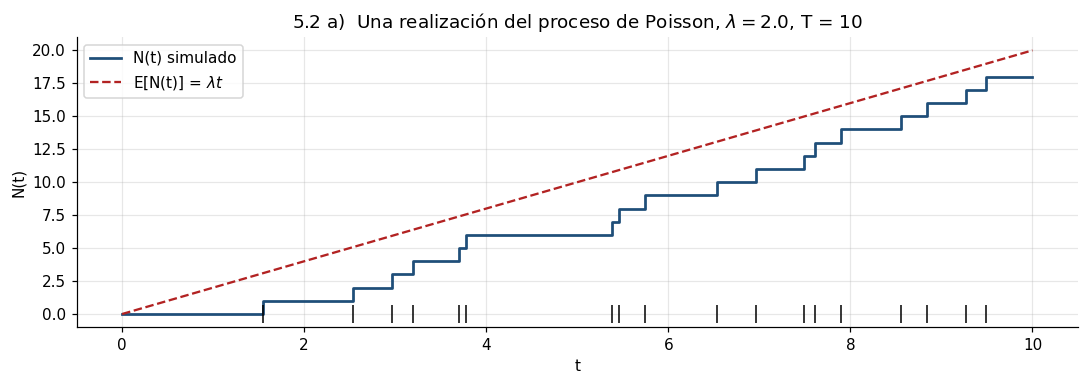

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.step(np.r_[0, S, T], np.r_[0, np.arange(1, len(S) + 1), len(S)], where="post", color="#1f4e79", lw=1.8, label="N(t) simulado")
ax.plot([0, T], [0, LAM * T], "--", color=COLOR_LINEA, label="E[N(t)] = $\\lambda t$")
ax.plot(S, np.zeros_like(S), "|", color="k", ms=12)
ax.set_xlabel("t"); ax.set_ylabel("N(t)"); ax.set_title(f"5.2 a)  Una realización del proceso de Poisson, $\\lambda = {LAM}$, T = {T:.0f}")
ax.legend(); plt.tight_layout(); plt.show()

Una sola realización no dice mucho. Para comprobar que el programa genera de verdad un proceso de
Poisson se repite 1000 veces y se revisan tres propiedades: $N(T)$ debe ser Poisson de media
$\lambda T = 20$, el primer tiempo entre eventos $S(1)$ debe ser exponencial de tasa 2, y, dado el
número de eventos, sus tiempos de ocurrencia deben estar repartidos uniformemente en $[0, T]$.

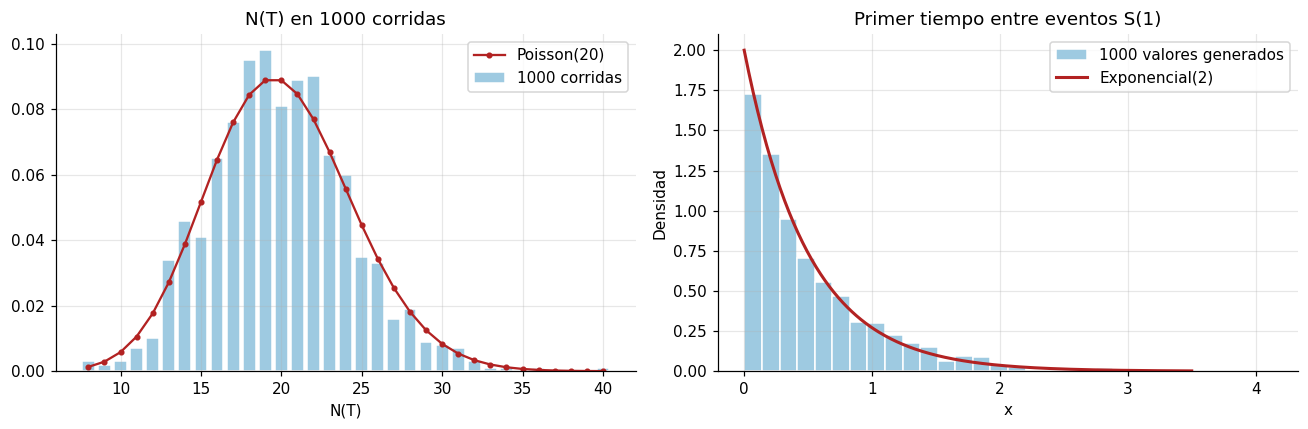

N(T): media = 19.955, varianza = 18.642   (teóricas: 20 y 20)
S(1): media = 0.5167 (teórica 0,5), KS D = 0.0240, p = 0.6020
Tiempos de ocurrencia vs U(0, 10): n = 19955, KS D = 0.0046, p = 0.7944
Todos los tiempos entre eventos juntos: media = 0.4778, KS D = 0.0184, p = 0.0000


In [13]:
g = GCM(semilla=506)
corridas = [proceso_poisson(g, LAM, T) for _ in range(1000)]
N_T = np.array([len(s) for s in corridas])
primer = np.array([s[0] for s in corridas if len(s) > 0])
todos = np.concatenate(corridas)
entre = np.concatenate([np.diff(np.r_[0, s]) for s in corridas])   # todos los tiempos entre eventos juntos

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
k = np.arange(N_T.min(), N_T.max() + 1)
frec = np.array([(N_T == v).mean() for v in k])
axs[0].bar(k, frec, color=COLOR_HIST, edgecolor="white", label="1000 corridas")
axs[0].plot(k, stats.poisson.pmf(k, LAM * T), "o-", color=COLOR_LINEA, ms=3, label="Poisson(20)")
axs[0].set_title("N(T) en 1000 corridas"); axs[0].set_xlabel("N(T)"); axs[0].legend()
graficar(axs[1], primer, lambda x: LAM * math.exp(-LAM * x), np.linspace(0, 3.5, 300), "Primer tiempo entre eventos S(1)", bins=30, etiqueta="Exponencial(2)")
plt.tight_layout(); plt.show()

ks_primer = stats.kstest(primer, stats.expon(scale=1 / LAM).cdf)
ks_unif = stats.kstest(todos, stats.uniform(0, T).cdf)
ks_entre = stats.kstest(entre, stats.expon(scale=1 / LAM).cdf)
print(f"N(T): media = {N_T.mean():.3f}, varianza = {N_T.var(ddof=1):.3f}   (teóricas: 20 y 20)")
print(f"S(1): media = {primer.mean():.4f} (teórica 0,5), KS D = {ks_primer.statistic:.4f}, p = {ks_primer.pvalue:.4f}")
print(f"Tiempos de ocurrencia vs U(0, {T:.0f}): n = {len(todos)}, KS D = {ks_unif.statistic:.4f}, p = {ks_unif.pvalue:.4f}")
print(f"Todos los tiempos entre eventos juntos: media = {entre.mean():.4f}, KS D = {ks_entre.statistic:.4f}, p = {ks_entre.pvalue:.4f}")

La media y la varianza de $N(T)$ quedan cerca de 20, como corresponde a una Poisson, el primer
tiempo entre eventos sigue la exponencial de tasa 2 y los tiempos de ocurrencia pasan la prueba de
uniformidad en $[0, 10]$.

La última línea muestra algo que me encontré al validar. La primera idea fue juntar todos los tiempos
entre eventos de las 1000 corridas y compararlos con la exponencial, y Kolmogorov-Smirnov los rechazó
con una media de 0,478 en vez de 0,5. El generador no tiene nada malo: al cortar cada corrida en
$T = 10$ se descarta el último tramo, que es el que no alcanzó a terminar, y los tramos largos tienen
más probabilidad de quedar cortados. La muestra queda sesgada hacia valores pequeños. Por eso la
comparación correcta es con $S(1)$, que prácticamente nunca pasa de $T$ ($P\{S(1) > 10\} = e^{-20}$).

#### b) Variable aleatoria de Coxian

El trabajador pasa por las etapas $1, 2, \dots, k$. La etapa $i$ dura una exponencial de tasa
$\lambda_i$ y, al terminarla, sigue con la etapa $i+1$ con probabilidad $\alpha_i$ o se detiene con
probabilidad $1 - \alpha_i$. $X$ es el tiempo total. Al terminar la etapa $k$ el trabajo se acaba
de todas formas, así que $\alpha_k$ no interviene.

**Algoritmo:**

1. $X = 0$, $i = 1$.
2. Generar $U_1$ y hacer $X = X - \frac{1}{\lambda_i}\ln U_1$.
3. Si $i = k$, devolver $X$.
4. Generar $U_2$. Si $U_2 > \alpha_i$, devolver $X$ (el trabajador se detiene).
5. $i = i + 1$ y volver al paso 2.

Para comprobarlo se usan dos resultados teóricos. La probabilidad de terminar justo en la etapa $i$
es $\alpha_1\cdots\alpha_{i-1}(1-\alpha_i)$, y la media es

$$E[X] = \sum_{i=1}^{k}\frac{\alpha_1\alpha_2\cdots\alpha_{i-1}}{\lambda_i}.$$

Además, $X$ es una distribución tipo fase: con vector inicial $\mathbf{a} = (1, 0, \dots, 0)$ y la
matriz $\mathbf{S}$ que tiene $-\lambda_i$ en la diagonal y $\alpha_i\lambda_i$ encima de ella, la
densidad es $f(x) = \mathbf{a}\,e^{\mathbf{S}x}\,\mathbf{s}_0$ con $\mathbf{s}_0 = -\mathbf{S}\mathbf{1}$.
Eso permite dibujar la curva teórica exacta sobre el histograma.

Ejemplo: $k = 3$, $\lambda = (1;\ 2;\ 0{,}5)$ y $\alpha = (0{,}7;\ 0{,}4)$.

Primeros 10 valores: [2.9135 1.2116 5.4517 3.4498 0.2087 0.595  0.2516 0.6252 0.793  4.27  ]
 Etapa final  Frecuencia sim.  Prob. teórica
           1           0.3000         0.3000
           2           0.4190         0.4200
           3           0.2810         0.2800

Media simulada = 1.9736   media teórica = 1.9100
Kolmogorov-Smirnov: D = 0.0306, p = 0.3020


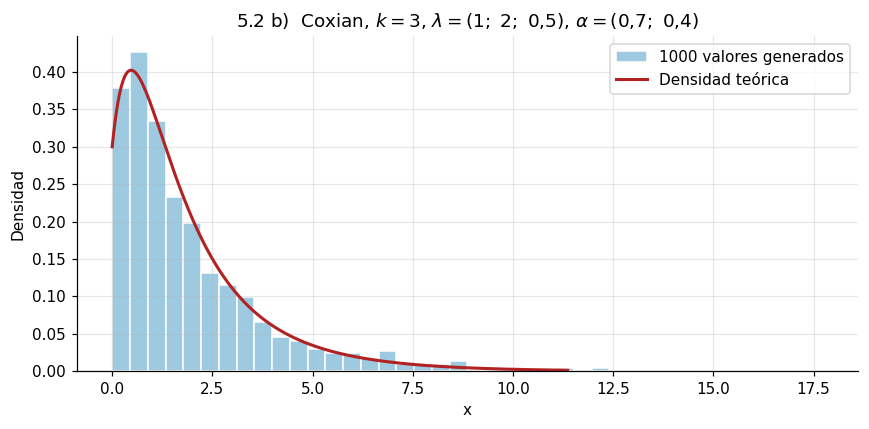

In [14]:
def coxian(g, lams, alfas):
    x = 0.0
    for i, lam in enumerate(lams):
        x -= math.log(g.u()) / lam
        if i == len(lams) - 1 or g.u() > alfas[i]:
            return x, i + 1          # tiempo total y etapa en la que se detuvo

def matriz_coxian(lams, alfas):
    k = len(lams)
    Smat = np.diag([-l for l in lams]).astype(float)
    for i in range(k - 1):
        Smat[i, i + 1] = alfas[i] * lams[i]
    return Smat

def coxian_pdf(lams, alfas):
    Smat = matriz_coxian(lams, alfas)
    s0, a0 = -Smat.sum(axis=1), np.eye(len(lams))[0]
    return lambda x: float(a0 @ expm(Smat * x) @ s0) if x >= 0 else 0.0

def coxian_cdf(lams, alfas):
    Smat = matriz_coxian(lams, alfas)
    a0, uno = np.eye(len(lams))[0], np.ones(len(lams))
    return lambda xv: np.array([1 - a0 @ expm(Smat * x) @ uno for x in np.atleast_1d(xv)])

lams_cx, alfas_cx = [1.0, 2.0, 0.5], [0.7, 0.4]
g = GCM(semilla=606)
salida = [coxian(g, lams_cx, alfas_cx) for _ in range(1000)]
x_cx = np.array([s[0] for s in salida])
etapa = np.array([s[1] for s in salida])

prob_llegar = np.cumprod([1.0] + alfas_cx)            # P(llegar a la etapa i)
media_cx = sum(p / l for p, l in zip(prob_llegar, lams_cx))
p_fin = [prob_llegar[i] * (1 - (alfas_cx + [0.0])[i]) for i in range(3)]

print("Primeros 10 valores:", np.round(x_cx[:10], 4))
print(pd.DataFrame({"Etapa final": [1, 2, 3],
                    "Frecuencia sim.": [(etapa == i).mean() for i in (1, 2, 3)],
                    "Prob. teórica": p_fin}).to_string(index=False))
ks_cx = stats.kstest(x_cx, coxian_cdf(lams_cx, alfas_cx))
print(f"\nMedia simulada = {x_cx.mean():.4f}   media teórica = {media_cx:.4f}")
print(f"Kolmogorov-Smirnov: D = {ks_cx.statistic:.4f}, p = {ks_cx.pvalue:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
graficar(ax, x_cx, coxian_pdf(lams_cx, alfas_cx), np.linspace(0, np.quantile(x_cx, 0.995), 300),
         "5.2 b)  Coxian, $k=3$, $\\lambda=(1;\\ 2;\\ 0{,}5)$, $\\alpha=(0{,}7;\\ 0{,}4)$", bins=40)
plt.tight_layout(); plt.show()

Las frecuencias con que el trabajador se detiene en cada etapa coinciden con las probabilidades
$0{,}30$, $0{,}42$ y $0{,}28$, y la media simulada queda cerca de la teórica
$1 + 0{,}7/2 + 0{,}28/0{,}5 = 1{,}91$. La densidad tiene una forma que ninguna exponencial sola
reproduce: arranca en $f(0) = \lambda_1(1 - \alpha_1) = 0{,}3$ (el que se detiene en la primera
etapa) y tiene una cola larga por la etapa 3, que es la más lenta.

---

### 5.3 Generando procesos de Poisson no homogéneos

Función de intensidad:

$$\lambda(t) = \begin{cases} \dfrac{t}{5}, & 0 < t < 5,\\[2mm] 1 + 5(t - 5), & 5 < t < 10.\end{cases}$$

Las dos ramas valen 1 en $t = 5$, así que la función es continua y creciente, con máximo
$\lambda(10) = 26$. El número esperado de eventos en $[0, 10]$ es

$$m(10) = \int_0^{5}\frac{t}{5}\,dt + \int_5^{10}\big(1 + 5(t-5)\big)\,dt = 2{,}5 + 67{,}5 = 70.$$

**Algoritmo de adelgazamiento** (sección 5.5 de [Ross99]) con $\lambda = 26$:

1. $t = 0$, $I = 0$.
2. Generar $U$.
3. $t = t - \frac{1}{\lambda}\ln U$. Si $t > T$, parar.
4. Generar $U$.
5. Si $U \le \lambda(t)/\lambda$, hacer $I = I + 1$, $S(I) = t$.
6. Volver al paso 2.

Como $\lambda(t)$ es muy pequeña al comienzo, con $\lambda = 26$ se van a rechazar casi todos los
candidatos de la primera mitad. Ross propone partir el intervalo y usar una cota distinta en cada
parte. Aquí el corte natural es $t = 5$, con $\lambda_1 = 1$ en $[0, 5]$ y $\lambda_2 = 26$ en
$[5, 10]$. También se implementa esa versión para comparar.

In [15]:
def intensidad(t):
    return t / 5 if t < 5 else 1 + 5 * (t - 5)

def m_acum(t):
    # integral de la intensidad entre 0 y t
    t = np.asarray(t, dtype=float)
    return np.where(t <= 5, t ** 2 / 10, 2.5 + (t - 5) + 2.5 * (t - 5) ** 2)

def ppnh_adelgazamiento(g, lam_t, lam, T):
    t, S, candidatos = 0.0, [], 0
    while True:
        t -= math.log(g.u()) / lam
        if t > T:
            return np.array(S), candidatos
        candidatos += 1
        if g.u() <= lam_t(t) / lam:
            S.append(t)

def ppnh_por_intervalos(g, lam_t, cortes, lams):
    # cortes = [t_0=0, t_1, ..., t_k=T];  lams[j] >= lam_t(s) en [t_j, t_{j+1}]
    t, J, S, candidatos = 0.0, 0, [], 0
    X = -math.log(g.u()) / lams[J]
    while True:
        while t + X > cortes[J + 1]:                # el candidato se sale del subintervalo
            if J == len(lams) - 1:
                return np.array(S), candidatos
            X = (X - (cortes[J + 1] - t)) * lams[J] / lams[J + 1]
            t, J = cortes[J + 1], J + 1
        t += X
        candidatos += 1
        if g.u() <= lam_t(t) / lams[J]:
            S.append(t)
        X = -math.log(g.u()) / lams[J]

T_NH, LAM_MAX = 10.0, 26.0
g = GCM(semilla=707)
S_nh, cand = ppnh_adelgazamiento(g, intensidad, LAM_MAX, T_NH)
print(f"Adelgazamiento (lambda = 26): {cand} candidatos, {len(S_nh)} eventos aceptados")
print(f"Eventos en (0, 5]: {np.sum(S_nh <= 5)}   eventos en (5, 10]: {np.sum(S_nh > 5)}")
print("Tiempos de los eventos:")
print(np.round(S_nh, 3))

Adelgazamiento (lambda = 26): 252 candidatos, 69 eventos aceptados
Eventos en (0, 5]: 4   eventos en (5, 10]: 65
Tiempos de los eventos:
[1.669 3.115 4.467 4.582 5.537 5.778 6.002 6.045 6.077 6.368 6.417 6.711
 6.772 6.921 6.982 7.052 7.189 7.317 7.532 7.55  7.569 7.716 7.744 7.76
 7.822 7.834 7.845 7.93  7.934 7.948 7.992 8.125 8.166 8.207 8.327 8.386
 8.401 8.505 8.514 8.556 8.559 8.619 8.619 8.619 8.627 8.635 8.72  8.865
 8.872 8.9   8.994 9.058 9.089 9.172 9.294 9.317 9.33  9.35  9.421 9.466
 9.472 9.549 9.622 9.705 9.716 9.718 9.827 9.842 9.967]


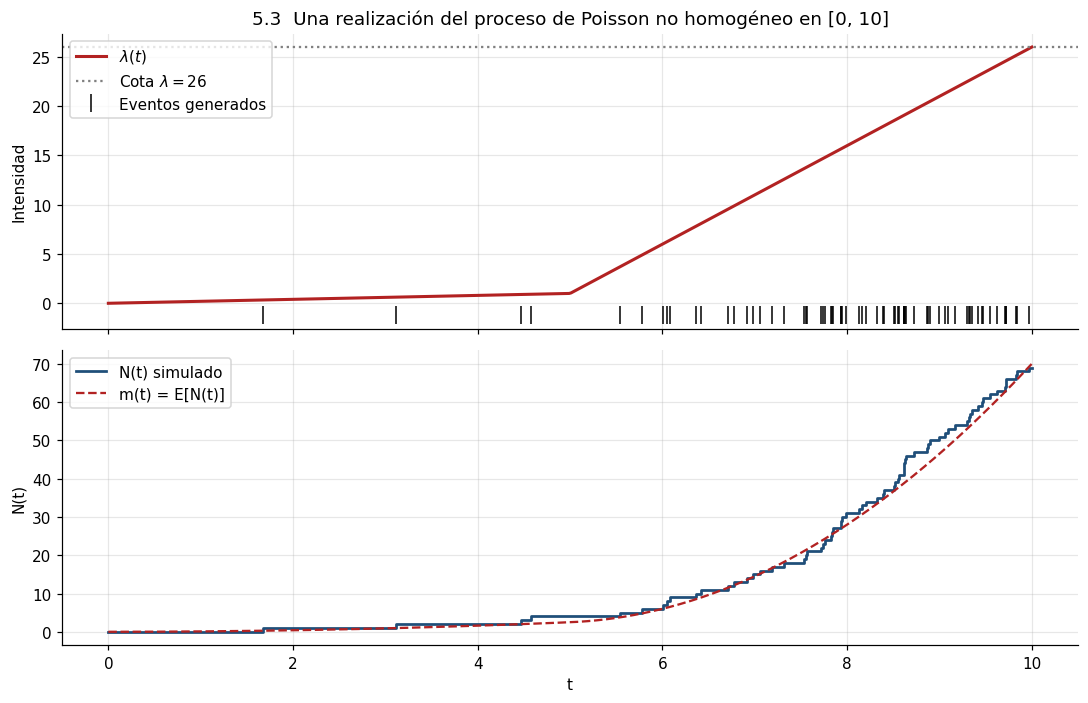

In [16]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
ts = np.linspace(0, T_NH, 500)
axs[0].plot(ts, [intensidad(v) for v in ts], color=COLOR_LINEA, lw=2, label="$\\lambda(t)$")
axs[0].axhline(LAM_MAX, color="gray", ls=":", label="Cota $\\lambda = 26$")
axs[0].plot(S_nh, np.full_like(S_nh, -1.2), "|", color="k", ms=12, label="Eventos generados")
axs[0].set_ylabel("Intensidad"); axs[0].legend(loc="upper left")
axs[0].set_title("5.3  Una realización del proceso de Poisson no homogéneo en [0, 10]")
axs[1].step(np.r_[0, S_nh, T_NH], np.r_[0, np.arange(1, len(S_nh) + 1), len(S_nh)], where="post",
            color="#1f4e79", lw=1.8, label="N(t) simulado")
axs[1].plot(ts, m_acum(ts), "--", color=COLOR_LINEA, label="m(t) = E[N(t)]")
axs[1].set_xlabel("t"); axs[1].set_ylabel("N(t)"); axs[1].legend(loc="upper left")
plt.tight_layout(); plt.show()

Igual que en el 5.2 a), se repite 1000 veces con cada versión del algoritmo. Si están bien, $N(10)$
debe ser Poisson de media 70 y los tiempos de los eventos, juntados, deben tener densidad
$\lambda(t)/m(10) = \lambda(t)/70$ en $[0, 10]$.

In [17]:
def repetir(generador, n_rep, semilla):
    g = GCM(semilla=semilla)
    res = [generador(g) for _ in range(n_rep)]
    N = np.array([len(r[0]) for r in res])
    cand = np.array([r[1] for r in res])
    tiempos = np.concatenate([r[0] for r in res])
    return N, cand, tiempos

N_ad, cand_ad, t_ad = repetir(lambda g: ppnh_adelgazamiento(g, intensidad, LAM_MAX, T_NH), 1000, 708)
N_iv, cand_iv, t_iv = repetir(lambda g: ppnh_por_intervalos(g, intensidad, [0, 5, 10], [1.0, 26.0]), 1000, 709)

comp = pd.DataFrame({
    "Algoritmo": ["Adelgazamiento, lambda = 26", "Por intervalos, lambda = (1; 26)"],
    "Media N(10)": [N_ad.mean(), N_iv.mean()],
    "Var. N(10)": [N_ad.var(ddof=1), N_iv.var(ddof=1)],
    "Candidatos prom.": [cand_ad.mean(), cand_iv.mean()],
    "Candidatos teór.": [26 * 10, 1 * 5 + 26 * 5],
    "Tasa de aceptación": [N_ad.sum() / cand_ad.sum(), N_iv.sum() / cand_iv.sum()],
    "KS tiempos (p)": [stats.kstest(t_ad, lambda x: m_acum(x) / 70).pvalue,
                       stats.kstest(t_iv, lambda x: m_acum(x) / 70).pvalue],
})
comp

,Algoritmo,Media N(10),Var. N(10),Candidatos prom.,Candidatos teór.,Tasa de aceptación,KS tiempos (p)
0,"Adelgazamiento, lambda = 26",69.9980,68.4024,260.0490,260,0.2692,0.4108
1,"Por intervalos, lambda = (1; 26)",70.3550,73.2702,135.2900,135,0.5200,0.1517


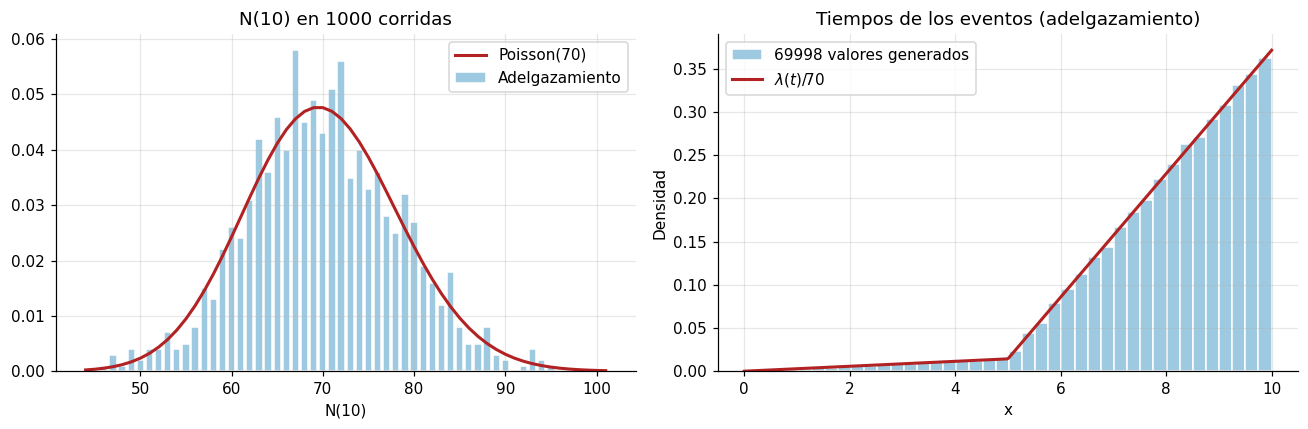

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
k = np.arange(min(N_ad.min(), N_iv.min()), max(N_ad.max(), N_iv.max()) + 1)
axs[0].bar(k, [(N_ad == v).mean() for v in k], color=COLOR_HIST, edgecolor="white", label="Adelgazamiento")
axs[0].plot(k, stats.poisson.pmf(k, 70), color=COLOR_LINEA, lw=2, label="Poisson(70)")
axs[0].set_title("N(10) en 1000 corridas"); axs[0].set_xlabel("N(10)"); axs[0].legend()
graficar(axs[1], t_ad, lambda x: intensidad(x) / 70 if 0 <= x <= 10 else 0.0, np.linspace(0, 10, 400),
         "Tiempos de los eventos (adelgazamiento)", bins=40, etiqueta="$\\lambda(t)/70$", loc="upper left")
plt.tight_layout(); plt.show()

Los dos algoritmos generan el mismo proceso: $N(10)$ tiene media y varianza cercanas a 70 y los
tiempos de los eventos siguen la forma de $\lambda(t)$, casi nada al principio y cada vez más hacia
$t = 10$. La diferencia es de eficiencia. Con una sola cota $\lambda = 26$ se generan unos 260
candidatos por corrida y solo se acepta alrededor del 27 %; casi todo lo que se desecha cae en
$[0, 5]$, donde $\lambda(t) \le 1$. Separando el intervalo en $t = 5$ los candidatos bajan a unos
135 y la aceptación sube a cerca del 52 %, sin cambiar el resultado. Se podría afinar más con
subintervalos más cortos en $[5, 10]$, porque allí $\lambda(t)$ también crece mucho.

---

## Referencias

- [Ross99] Ross, S. M. *Simulación*, 2.ª edición. Prentice Hall, 1999. Capítulo 5: Generación de variables aleatorias continuas.
- [Ross13] Ross, S. M. *Simulation*, 5th edition. Academic Press, 2013.
- Cruz Roa, A. A. *Generación de variables aleatorias continuas*. Diapositivas del curso Simulación Computacional, Universidad de los Llanos.